# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
The objective of this project is to create a model that is able to predict the tax values of properties from relevant characteristics. Preliminary exploration of the dataset providing training and testing data revealed limitations necessary to address. After cleaning the data, the result was an easily interpretable dataset without redundancy or missing values. We also  investigated the relationships between the features in this cleaned dataset in preparation for building our model, which provided insight into potential subsets of features that could yield strong predictions.
  
We chose to build and test three different models: a linear regression model, decision tree model, and random forest model in order to test linear and nonlinear models. We made adjustments to the models incrementally in an attempt to maximize performance, observing how overall performance (average value of errors made) and stability changed with each step. After creating the baseline models, we tested added features we had transformed so the models might be able to find the underlying patterns more easily, using feature sets found to have the most predictive power from selection techniques, and tuning parameters of each model. We found that while model performance and stability fluctated with each step, the random forest model always had the best overall performance and stability in comparison to the other models. While the linear regression and decision tree models made errors around `$186`k and `$215`k respectively, the random forest model made errors around `$161`k. Stability was also robust, the model's predictions lying around `$1300-1500` from the average with each repeated test during training. The most important features used to make these predictions were found to be square footage of finished living area and lot, latitude and longitude, and age. Thus, square footage, location, and age are the most relevant indictors of tax value. In the end, the random forest model was able to maintain this error on data it had not seen, demonstrating it had not just memorized the data and had found the underlying patterns in it.

The random forest model consistently made the lowest errors in prediction on average and had the greatest stability in comparison to the other tested models. Additionally, the model maintained its strong performance when fed new, unseen data, demonstrating powerful generalization ability. Based on all of the above information, we recommend using our tuned random forest regression model to predict tax valuations for properties.

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
As part of an in-house data science team at a real estate company, our focus is improving property valuations using past documented housing data. Current techniques lack knowledge about which features possess the most predictive power for property tax valuation as well as the relationships between the features. Existing models may also not be optimized for performance in this area due to lack of hyperparameter tuning. These hidden patterns in the real estate market alongside non-optimal model performance can cause inaccurate property valuation, negatively impacting decision-making made by real-estate professionals and thus business outcomes for the company.  
  
The objective of this project is to improve the reliability of property tax valuations, which will enable real estate professionals to make more informed decisions regarding property sales. To complete this goal, this project will clean a dataset containing historical housing data, analyze relationships between features, and optimize model performance. We aim to build a regression model that tests engineered and selected features with tuned hyperparameters in order to predict property tax values with maximized performance.

## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
We used a subset of the Zillow housing dataset originally associated with the Zillow Prize competition, obtained from the course data URL (zillow_dataset.csv). The dataset describes individual properties using structural, geographic, and tax-related variables.

The raw extract contains 77,613 rows and 55 columns. After applying the Milestone 1 cleaning pipeline (feature removal, filtering, imputation, and encoding—detailed in §4.2), the final modeling table includes 75,834 observations and 19 columns (18 features plus the target).

Variable types: Most variables are numeric (int64/float64), including counts (e.g., bedrooms, bathrooms), continuous measures (e.g., finished square footage, lot size), and spatial coordinates (latitude, longitude). Several nominal codes (e.g., land-use and system identifiers) behave as categorical variables rather than continuous features and were treated accordingly. A small number of string/object variables (e.g., zoning, county land-use codes) were ordinal-encoded. Boolean-like indicators (e.g., tax delinquency, hot tub presence) were converted into numeric flags.

Target variable: taxvaluedollarcnt, representing the assessed property tax value in dollars. All supervised models aim to predict this value from the feature set.

Data quality issues: The dataset exhibits substantial and uneven missingness—many columns are largely null, while others contain sparse but potentially informative entries. Redundancy is also present (e.g., multiple geographic encodings or bathroom-related fields), and some columns function as identifiers (parcelid) with no predictive generalization value. The target variable is strongly right-skewed, with a long tail of high-value properties and extreme outliers that can dominate error metrics. Additionally, some missing values are semantically meaningful (e.g., absence of a pool versus unknown). These challenges motivated targeted feature removal, row filtering rules, IQR-based outlier handling (with a high multiplier to retain expensive properties), and type-specific imputation strategies.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
We began the project with an exploration of the data. Preliminary exploration revealed information such as the features, number of entries, and value datatypes. Univariate analysis revealed the distributions of the features as well as the proportions of missing values and other potentially disqualifying characteristics. Next, we cleaned the data, dropping features that would be unsuitable for our building our regression model. Features were dropped due to rendundancy or if it was missing more than 67% of its values. This particular threshold was chosen after observing there was a large gap of ~31% between the column with a missing value percentage of 67.8% and the column with the next highest of 36.1% (there were some exceptions made based on the meaning of the column's null values). Then, samples were dropped based on the following reasons: more than half its values being null, missing value in the target column, or outlier in the target column. Missing values were then imputed (null -> 0, skewed -> median) and categorical features encoded. In preparation for building our model, we performed a general investigation of relationships between features using a correlation heatmap, f-statistic, and forward and backward feature selection. This gave us clues about what the best feature set for our model might be. We finished by transforming some features we thought might improve model performance, including a log transformation of 'calculatedfinishedsquarefeet' (to improve distribution) and combining finished size and lot to increase interpretability.  
  
After completing the above steps, we began building potential models. We decided to build three baseline models: linear regression, decision tree, and random forest models, namely. We chose these models because we wanted at least one linear model and one tree model (linear versus nonlinear), and since we believed a tree model might be stronger due to its ability to capture nonlinear relationships we chose two. Our baseline models included cross validation with 5 folds and 5 repeats and reported both mean CV MAE and standard deviation of CV MAE. This means that following an initial train-test split (80% training, 20% test), the models split the training data 5 times (folds) and predict, for 5 rounds (repeats). The mean CV MAE reports the average magnitude of prediction mistakes across folds/repeats, while the standard deviation of the CV MAE demonstrates how far the scores are from the average across folds/repeats. Together these illustrate overall model performance and stability. MAE, in contrast to RMSE, penalizes errors proportionately and is robust against outliers. It is also highly interpretable, making it an ideal candidate for our business purpose. We chose not to use validation curves to prevent redundancy. We then added our transformed features into the dataset and trained the models with them to see if model performance improved, reporting the same metrics. We then trained the models again with feature sets generated from forward and backward feature selections to improve model performance, reporting the same metrics. Our final test involved tuning hyperparameters for the decision tree and random forest models (since this cannot be done to the linear regression model) to see if model performance improved, reporting the same metrics. We then chose our best model based on it having the lowest mean CV MAE and standard deviation of CV MAE, which was the tuned random forest regressor. This model was ran a final time, this time reporting test MAE alongside the others in order to evaluate its performance on unseen data.


### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  

Issues in the raw data: The Zillow extract exhibited significant missingness (many columns largely null), redundant geographic and bathroom-related variables, identifier-like fields that do not generalize (e.g., parcelid), and a highly skewed target (taxvaluedollarcnt) with extreme upper-tail values. Some missing values are semantically meaningful (e.g., no pool or hot tub rather than unknown).

Feature removal: We removed identifiers and near-constant fields (e.g., parcelid, assessmentyear), consolidated redundant location variables in favor of latitude/longitude, and dropped duplicate or less complete area/bathroom measures while retaining more comprehensive variables (e.g., calculatedfinishedsquarefeet). Columns with more than ~67% missingness were dropped, except for cases where null values encode absence (e.g., pool, hot tub, delinquency flag), which were preserved intentionally.

Sample filtering: Rows were excluded if they contained nulls in at least half of the columns, if the target variable was missing, or if the target was identified as an extreme outlier using an IQR-based rule. Given the strong right skew of the target, we applied a large IQR multiplier (5) to remove only the most extreme values while preserving high-end properties.

Imputation: Rows with sporadic missingness in otherwise complete fields (e.g., yearbuilt, calculatedfinishedsquarefeet) were dropped. For remaining features, count and flag variables where NaN implied “none” were imputed with 0. Skewed numeric variables (e.g., lotsizesquarefeet, unitcnt) were imputed using the median, while categorical-style variables used the mode. Cleaned categorical variables were then ordinal-encoded.

What worked: The pipeline produced a clean, fully numeric feature matrix suitable for both linear and tree-based models, reduced leakage-prone identifiers, and preserved informative missingness without introducing artificial values.

Trade-offs: Aggressive removal of sparse columns likely discarded rare but potentially useful signals (e.g., pool or deck features). Ordinal encoding introduces arbitrary ordering in categorical variables such as zoning codes. Additionally, we did not log-transform the target despite its skewness—this improves interpretability in dollar terms but increases the likelihood of heteroskedastic errors, which is revisited in §5.3.

### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  

The first feature transformation performed was a log transformation on the 'calculatedfinishedsquarefeet' column. This was done to reduce the effect of the feature's highly right-skewed distribution that was seen in boxplot and histrogram visualizations. However, we observed that the correlation between 'calculatedfinishedsquarefeet' and the target variable was greater than the correlation between 'log_calculatedfinishedsquarefeet' and the target variable, indicating that the log transformation weakened the relationship between finished square feet of a property and its assessed tax value. While the transformed column was chosen in all subsets during feature selection, it was assigned nearly equal feature importance to the original column across all three models. 

The second feature transformaton was a to convert the 'yearbuilt' feature 'age' defined as the difference between the current year (2026) and the year the property was built. This linear transformation was performed to make the feature more interpretable and directly relevant to property valuation, as the age of a home is often more meaningful than the raw construction year. This transformation appeared to have little impact on model performance where it was assigned nearly equal feature importance across all three models.

We chose to include a new feature, 'finished_to_lot_ratio', which is defined as 'calculatedfinishedsquarefeet' divided by ('lotsizesquarefeet' + 1). Adding 1 to the denominator prevents division by zero when lot size is zero or missing after cleaning. Large values indicate more finished area relative to lot size (denser development), while small values indicate a relatively land-heavy parcel. Thus, this feature was believed to be useful because it captures how intensively the land is developed, which is not fully represented by either finished square feet or lot size alone. Notably, this feature was only retained by the random forest and decision tree models during feature selection where it had the 6th and 5th highest feature importance respectively. We believe this feature was not chosen in the linear regression model potentially due to the due to the high right-skew observed in the feature's distribution. This may have introduced nonlinearity that cannot be captured by properly capture by a linear model.

When all three feature transformations were included, none of the models showed significant improvement in performance. The linear regression model showed miniscule improvement in mean CV MAE, with a slightly worse standard deviation of CV MAE. The decision tree model had a slightly worse mean CV MAE, with a slightly better standard deviation of CV MAE. Finally, the random forest model had worse scores in both mean CV MAE and standard deviation of CV MAE.  

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  
The three models that were chosen to be evalued were a linear regression, decision tree, and random forest model. These models were selected to test the dataset on a range of model complexity and underlying assumptions. Linear regression was used as a baseline model due to its simplicity and its ability to capture linear relationships between features and the target variable. In contrast, the decision tree and random forest models were chosen to capture any nonlinear relationships that were assumed to be present based on exploratory data analysis previously performed. 

Generalization was evaluated by first creating an 80-20 train-test split of the dataset. In all baseline and tuning steps, each model's performance was determined through repeated 5-fold cross validation mean MAE and standard deviation of MAE. This helped reduce the risk of relying on a single train-test split and provided a better indication of how well each model generalizes to unseen data. Finally, the final model's performance on the held out test set was confirmed to match closely with its mean CV MAE further indicating its ability to generalize to unseen data. 

Hyperparameter tuning was performed on using a grid search on the random forest model and a randomized search on the decision tree model. The radon forest model's best parameters were 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, and 'n_estimators': 300. The decision tree's model best parameters were 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', and 'max_depth': 10.

The final model was chosen by observing that the random forest model consistently achieved the lowest cross-validated MAE across all stages of the modeling pipeline while maintaining low variance. The decision to select Random Forest was driven by its ability to capture complex nonlinear relationships and interactions between features, which are common in housing price prediction tasks. Linear Regression underperformed due to high bias and inability to model nonlinearities, while the Decision Tree exhibited higher variance and overfitting tendencies. Random Forest effectively mitigates this by averaging multiple decorrelated trees, resulting in improved generalization.

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
The key metric we used in our evaluation was mean absolute error (MAE). This measures the average magnitude of the prediction mistakes made by the model. We included multiple types of MAE: mean cross validation (CV) MAE, standard deviation of CV MAE, and test MAE. When evaluating our models, we wanted to know how well the models perform on unseen data. We thus used a train-test split and included a cross validation component to our models. This means that we initially split our data into a training split and a test set (80% and 20%, respectively, in our case), then the models we evaluate only are trained on the training set. Within that training, cross validation splits the data into k-folds and performs the training for k-repeats. Since we chose a value of 5 for each initially, this means there are 5 splits in the training data, and the splitting process repeats 5 times. After this, the model predicts on the test data, which it has never seen. The mean CV MAE is the average MAE calculated across k-folds and k-repeats, while the standard deviation of the CV MAE is how far the scores fall from the average. These communicate overall performance and stability. The test MAE is the average magnitude of the prediction mistakes made by the model on the unseen test set.

1. We decided to create three baseline models: linear regression, decision tree, and random forest. Before any feature engineering, the results were as follows:
- Linear Regression  
Mean CV MAE: 186977.0278  
Standard Deviation of CV MAE: 1149.2885  
The model was off by around `$186,977` on average, and each score was around `$1149` away from the mean score on average.
  
- Decision Tree  
Mean CV MAE: 214784.6902  
Standard Deviation of CV MAE: 2420.5086 
The model was off by around `$217,785` on average, and each score was around `$2421` away from the mean score on average.  
  
- Random Forest  
Mean CV MAE: 161119.1014  
Standard Deviation of CV MAE: 1384.2321  
The model was off by around `$161,119` on average, and each score was around `$1384` away from the mean score on average.  
  
The best overall prediction performance was done by the random forest model, which had the lowest mean CV MAE, while the most stable model was the linear regression model (since the standard deviation of its CV MAE was the lowest). This may be due to the random forest's ability to capture nonlinear relationships and start from a baseline a few strong features, though increased noise may decrease stability. 
  
2. After feature engineering:  
- Linear Regression  
Mean CV MAE: 186938.5779 
Standard Deviation of CV MAE: 1154.0445  
The model was off by around `$186,939` on average, and each score was around `$1154` away from the mean score on average.
  
- Decision Tree  
Mean CV MAE: 215606.7445  
Standard Deviation of CV MAE: 2171.4746 
The model was off by around `$215,607` on average, and each score was around `$2171` away from the mean score on average.  
  
- Random Forest  
Mean CV MAE: 161273.5090  
Standard Deviation of CV MAE: 1468.8747  
The model was off by around `$161,274` on average, and each score was around `$1469` away from the mean score on average.  
  
The best overall prediction performance was done by the random forest model, which had the lowest mean CV MAE, while the most stable model was the linear regression model (since the standard deviation of its CV MAE was the lowest). Overall performance slightly worsened for the decision tree and random forest models and slightly strengthened for the linear regression model after feature engineering, while stability slightly worsened for the linear regression and random forest models and slightly strengthened for the decision tree model. Feature engineering may have introduced noise that decreased performance for models that already captured nonlinear relationships, while giving new, helpful information to the linear regression model.
  
3. After feature selection:
- Linear Regression  
Mean CV MAE: 186798.7427 
Standard Deviation of CV MAE: 1189.5640 
The model was off by around `$186,799` on average, and each score was around `$1189` away from the mean score on average.
  
- Decision Tree  
Mean CV MAE: 215292.5463 
Standard Deviation of CV MAE: 2944.4494 
The model was off by around `$215,293` on average, and each score was around `$2944` away from the mean score on average.  
  
- Random Forest  
Mean CV MAE: 162350.6939 
Standard Deviation of CV MAE: 1501.7658 
The model was off by around `$162,350` on average, and each score was around `$1502` away from the mean score on average.  
  
The best overall prediction performance was done by the random forest model, which had the lowest mean CV MAE, while the most stable model was the linear regression model (since the standard deviation of its CV MAE was the lowest). Overall performance slightly worsened for the random forest model and slightly strengthened for the linear regression and decision tree models after feature selection, while stability slightly worsened for all models. As before, feature selection may introduce noise that decreases predictive power for models that already capture nonlinear relationships with a strong baseline of a few features while giving new, helpful information to other models.
  
4. After hyperparameter tuning:
- Decision Tree  
Mean CV MAE: 180607.3202 
Standard Deviation of CV MAE: 1689.1201 
The model was off by around `$180,607` on average, and each score was around `$1689` away from the mean score on average.  
  
- Random Forest  
Mean CV MAE: 161477.0804
Standard Deviation of CV MAE: 1513.3842
The model was off by around `$161,477` on average, and each score was around `$1513` away from the mean score on average.  
  
Since we could not tune hyperparameters for linear regression, we decided not to move forward with further testing. Between the remaining models, the best overall prediction performance was done by the random forest model, which had the lowest mean CV MAE, while the most stable model was also the random forest model (since the standard deviation of its CV MAE was the lowest). Overall performance slightly strengthened for both models after hyperparameter tuning, while stability strengthened for the decision tree model and slightly worsened for the random forest model. Hyperparameter tuning introduces complexity, which may make models more sensitive to the data.
  
When comparing across models, mean CV MAE communicates the overall performance of each model when training. It answers the question, "On average, how wrong are the predictions this model makes in the training set across folds and repeats?" A lower mean CV MAE is preferable. The standard deviation of the CV MAE communicates the stability of each model when training. A lower value for this metric indicates that the model performs similarly across folds and repeats, which is preferable. Finally, the test MAE reports the average magnitude of the mistakes the model makes for the test set, which demonstrates the model's overall performance on new data. A relatively low value is desired for this metric. We decided to move forward with our tuned random forest model since it had the lowest mean CV MAE and standard deviation of CV MAE overall.  
  
5. Final testing:  
- Random Forest  
Mean CV MAE (5 folds, 2 repeats): 161491.4162  
Standard deviation of CV MAE: 1303.5703 
Test MAE: 161254.6373
  
When comparing training versus test performance, the values are quite close, and test MAE is lower than the training mean CV MAE. This indicates strong generalization capability and a low probability of overfitting. During training, the model was off by around `$161,491` on average, while it was off by `$161,255` when predicting on unseen data. In comparison to the mean CV MAE, the standard deviation of the CV MAE is low, meaning the model is stable across folds. This model is a strong candidate for our business purpose.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  
The graph "F-Statistic for Features of Zillow Properties" depicts the ratio of explanied variance to unexplained variance of each feature compared to the target variable. In this context, higher F-statistic values indicate a stronger linear relationship with the target. This graph shows the features 'calculatedfinishedsquarefeet' and 'fullbathcnt' to have the highest linear relationships while, in contrast, the features 'unitcnt', 'longitude', and 'taxdelinquencyflag' to have the lowest. Both "calculatedfinishedsquarefeet" and 'fullbathcnt' were selected in the feature subset for the final random forest model as expected from their high F-statistic. However, an interesting observation is that the 'longitude' feature, despite having one of the lowest F-statistics, was still included in the final subset and ranked with the fourth highest feature importance score. This highlights an important limitation of the F-statistic being that it only captures linear relationships between individual features and the target variable. This is especially relevant to the 'longitude' feature as it is depends highly on its interaction with the 'latitude' feature to determine precise geographical location.

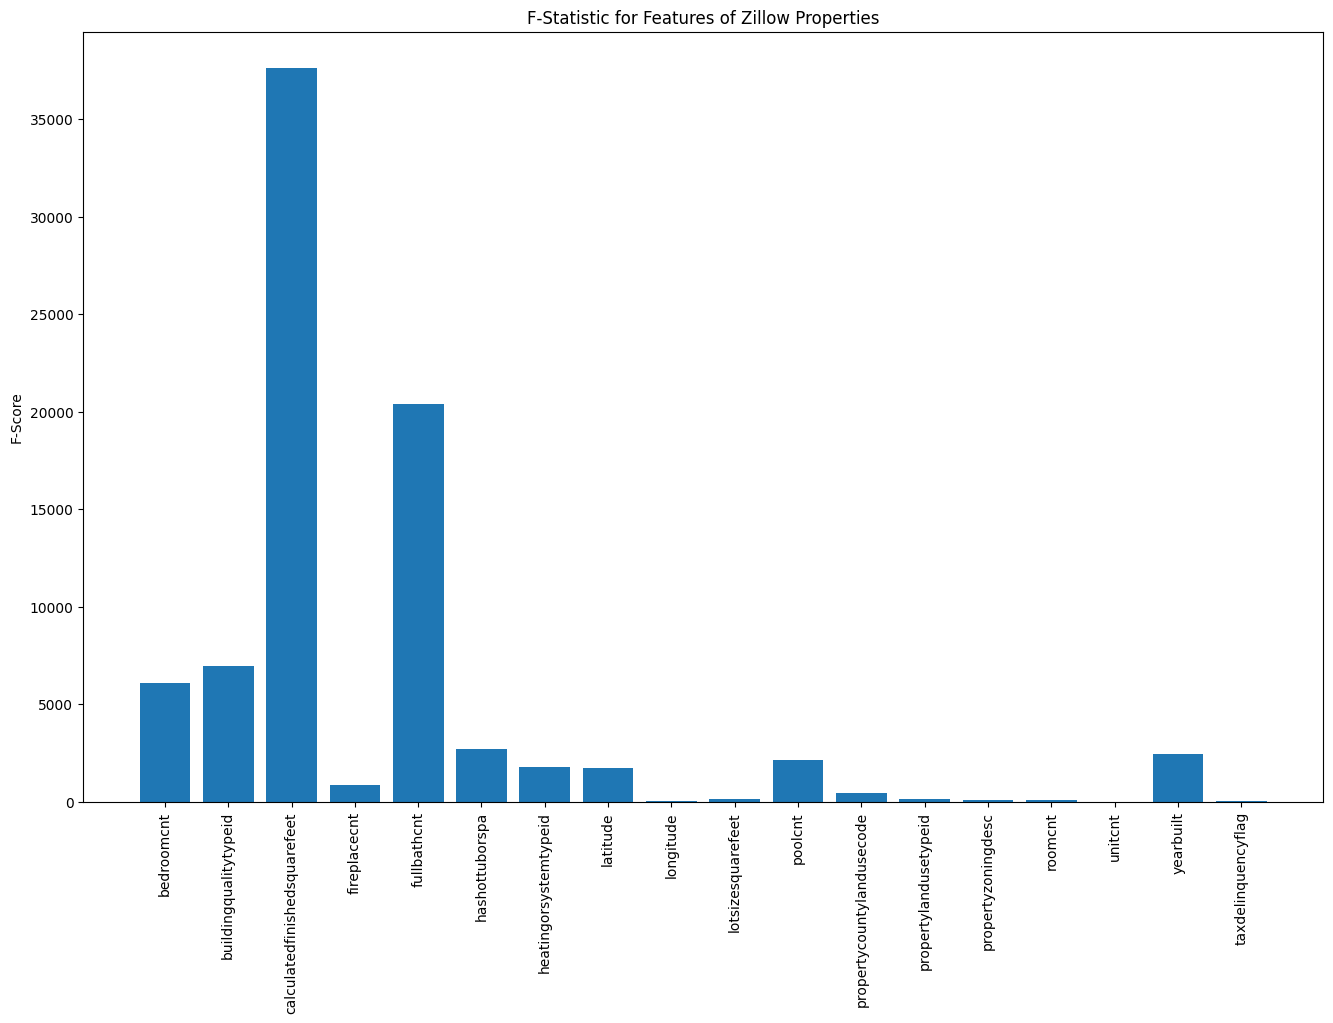


The graph "Forward Feature Selection and CV Scores" depicts the feature selection process performed on the linear regression model. At each step, it appends the feature that causes the highest reduction in the CV MAE of the model. One notable observation of the graph is that 'calculatedfinishedsquarefeet' was selected first over its log transformed conterpart, despite the transformation initially being included to reduce skew and improve linearity. This suggests that the original feature maintained a stronger linear relationship with the target variable, making it more effective for a linear model. After the feature 'poolcnt' was appened the CV MAE was seen to worsen and thus all remaing features were not selected for the linear model's final feature subset. Interestingly, two of the engineered features, 'finished_to_lot_ratio' and 'age', were not included in this subset. This suggests their relationship to the target variable may be nonlinear as they were both selected in the random forest and decision tree models. 

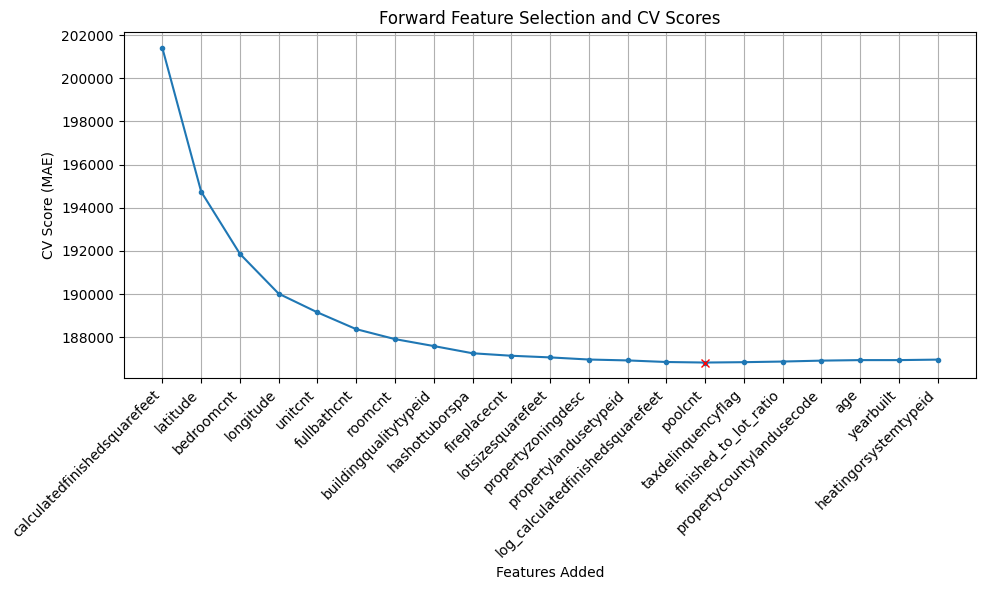

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  

We did not rely on a single residual analysis in Milestone 2 as a primary deliverable; however, error behavior can still be inferred from model structure, diagnostics (CV vs. test MAE), feature importance, and earlier model fit discussions.

Error patterns: The target (assessed tax value) is strongly right-skewed in dollar terms. For models trained on this scale - and evaluated with MAE - absolute errors naturally increase with property value. A given percentage error translates to larger dollar deviations for expensive homes, often producing fan-shaped residual dispersion unless the target is transformed. Feature importance results indicate that location (latitude/longitude) and size (calculatedfinishedsquarefeet) dominate predictions, suggesting spatially structured errors. Areas or segments with fewer comparable training examples may exhibit larger residuals.

Over- vs. underprediction: High-variance models (e.g., unregularized decision trees) showed instability, while linear regression underfit nonlinear relationships, leading to systematic bias in complex market segments. The Random Forest model provided the best balance, achieving the lowest cross-validation MAE. Its test MAE (~161k) closely matched cross-validation performance, indicating limited global bias across the holdout set. However, localized over- or underprediction likely persists, particularly for luxury or atypical properties.

Outliers and edge cases: Extreme-value properties were only partially trimmed using a wide IQR threshold, so the model may still struggle with very high-end homes or rare feature combinations. Additionally, dropping or sparsifying certain high-missingness features (e.g., pool or deck indicators) may leave some unusual properties under-characterized.

Surprises and next steps: Engineered features (e.g., log size, age, finished-to-lot ratio) did not consistently reduce CV MAE in isolation, though they remain relevant in nonlinear models where interactions matter. Future work should include explicit residual diagnostics: residual vs. fitted plots, MAE segmented by value decile, and spatial error mapping. These would help confirm asymmetry (e.g., regression-to-the-mean effects for extreme values) and guide further feature engineering and model refinement.


## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  

The analysis has several limitations based off of the structure of the raw dataset. Firstly, the target variable is highly right-skewed leading to luxury properties having disproportionately large influence on the overall error. This may reduce the model’s reliability when predicting properties in the lower and mid range, as errors in high-value homes can dominate the evaluation metrics. An attempt to reduce this skew with a log transformation on the target variable was explored through calculating F-statistics and forward feature selection on a linear model; however, all of the model analysis on the Random Forest and Decision Tree models was done on the original target variable. Secondly, it is important to note that this dataset does not include several potentially important predictors of property value. Some of these features not included are school districts, comparable property sales, and recent market conditions. The absence of these variables limits the model’s ability to be fully confident in predicting property value and likely contributes to residual error, particularly in rapidly changing markets. Finally, the decision to choose the Random Forest model was driven by desire to prioritize accuracy over interpretability. Thus, while the random forest Random Forest model provides strong predictive performance and generalization ability, it is significantly less interpretable than linear regression or shallow trees. As a result, the effects of individual feature can not be easily determined.

Future improvements could directly address these limitations by repeating all analysis steps using the log transformed target varible, incorporating additional datasets for improved socioeconomic and market trends, and using more advanced  models, such as XGBoost. Additional error analysis could be performed by analyzing residuals by geographic location or property value to help identify systematic patterns in prediction error.